In [43]:
#QUANTUM WELL SQUARE
import numpy as np
import matplotlib.pyplot as plt
import kwant

from scipy.constants import physical_constants

In [44]:
a = 0.5 * 10**(-9)
a_nm = a * 10**9
N = 40
L = (N+1)*a
L_nm = L*10**9
print("L=",L,"m")
print("L=",L/10**(-9),"nm")

L= 2.05e-08 m
L= 20.5 nm


In [45]:
h_bar = physical_constants['Planck constant over 2 pi'][0]
eV_unit = physical_constants['electron volt'][0]
m_el = physical_constants['electron mass'][0]

In [46]:
t = (h_bar**2) / (2*m_el*a**2)
t = t / eV_unit
print("t=",t)

t= 0.15239927954599816


In [47]:
sys = kwant.Builder()

In [48]:
lat = kwant.lattice.square(a_nm)

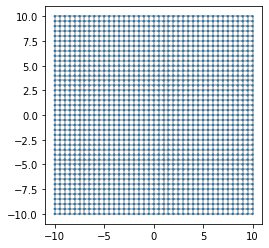

In [49]:
def square_shape(pos):
    (x,y) = pos
    if abs(x)<L_nm/2 and abs(y)<L_nm/2:
        return True
    else:
        return False
    
    
sys[lat.shape(square_shape, (0,0))] = 4*t
sys[lat.neighbors()] = -t

kwant.plot(sys);

In [50]:
sysf = sys.finalized()

In [51]:
Hmat = sysf.hamiltonian_submatrix()

In [52]:
ene, v = np.linalg.eigh(Hmat)

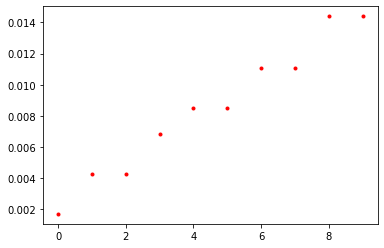

In [53]:
plt.plot(ene[:10], "r.");

In [54]:
from ipywidgets import interact

In [55]:
def plot_wf(n=0):
    kwant.plotter.map(sysf, abs(v[:,n])**2);

In [56]:
interact(plot_wf, n=(0,40))

interactive(children=(IntSlider(value=0, description='n', max=40), Output()), _dom_classes=('widget-interact',…

<function __main__.plot_wf(n=0)>